# [HW3] Сравнительный анализ EKF для оценки ориентации (Attitude Estimation)

Frolova AI

`https://github.com/kicchhi/Advanced-Robotics/tree/main`

Задача: Реализовать и сравнить два подхода к Extended Kalman Filter (EKF) для оценки ориентации смартфона: на углах Эйлера и на кватернионах.

Данные: Запишите единый лог данных (акселерометр + гироскоп) дома. Протокол записи:

▪ Положите телефон на стол неподвижно на 5–10 секунд (калибровка).
▪ Плавно вращайте телефон в руках по всем трем осям.
▪ Критический тест: Поверните телефон так, чтобы ось Pitch (тангаж) достигла 90 градусов (вертикально). Это проверка на Gimbal Lock.
▪ Верните телефон в исходное положение.
▪ Экспортируйте CSV (акселерометр в м/с², гироскоп в рад/с).


In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
# загрузка CSV
data = pd.read_csv("logs.csv", sep=";")
# удалить пустую колонку - загружается по ошиьке
data = data.drop(columns=["Unnamed: 7"])
# заменить запятые на точки
data = data.replace(",", ".", regex=True)
data = data.astype(float)

# извлечь данные
t = data["time"].values
acc = data[["ax","ay","az"]].values
gyro = data[["wx","wy","wz"]].values

# шаг времени
dt = np.mean(np.diff(t))

In [84]:
# нормализация вектора
# def normalize(v):
#     return v / (np.linalg.norm(v))

def normalize(v):
    n = np.linalg.norm(v)
    if n == 0:
        return v
    return v / n


# перевод кватерниона -> углы Эйлера
def quat_to_euler(q):

    w,x,y,z = q

    roll = np.arctan2(2*(w*x + y*z),1-2*(x*x+y*y))
    pitch = np.arcsin(2*(w*y - z*x))
    yaw = np.arctan2(2*(w*z + x*y),1-2*(y*y+z*z))

    return np.array([roll,pitch,yaw])

### EKF на углах Эйлера (Euler-based EKF)
Вектор состояния: `x = [roll, pitch, yaw]ᵀ`

Прогноз:

Используются показания гироскопа (wx, wy, wz) для интегрирования углов.

Уравнения кинематики:
```
roll_dot  = wx + sin(roll)*tan(pitch)*wy + cos(roll)*tan(pitch)*wz
pitch_dot = cos(roll)*wy - sin(roll)*wz
yaw_dot   = sin(roll)/cos(pitch)*wy + cos(roll)/cos(pitch)*wz
Проблема: деление на cos(pitch) — сингулярность при pitch = ±90° (Gimbal Lock).
```

Коррекция:

Используются показания акселерометра для вычисления углов наклона:

```
roll_meas  = arctan2(ay, az)
pitch_meas = arctan2(-ax, sqrt(ay² + az²))
Матрица наблюдения: H = [[1,0,0], [0,1,0], [0,0,0]] (Yaw не корректируется).
```


In [85]:
def ekf_euler(acc,gyro,dt):

    N = len(acc)

    x = np.zeros(3)        # roll pitch yaw
    P = np.eye(3)*0.01

    Q = np.eye(3)*0.001
    R = np.eye(3)*0.1

    result = []

    for i in range(N):

        wx,wy,wz = gyro[i]

        phi,theta,psi = x

        phi_dot = wx + np.sin(phi)*np.tan(theta)*wy + np.cos(phi)*np.tan(theta)*wz
        theta_dot = np.cos(phi)*wy - np.sin(phi)*wz
        psi_dot = np.sin(phi)/(np.cos(theta)+0.0000001)*wy + np.cos(phi)/(np.cos(theta)+0.00001)*wz

        x = x + dt*np.array([phi_dot,theta_dot,psi_dot])

        F = np.eye(3)
        P = F @ P @ F.T + Q

        ax,ay,az = normalize(acc[i])

        roll_meas = np.arctan2(ay,az)
        pitch_meas = np.arctan2(-ax,np.sqrt(ay**2+az**2))

        z = np.array([roll_meas,pitch_meas,0])

        H = np.array([
            [1,0,0],
            [0,1,0],
            [0,0,0]
        ])

        y = z - H@x

        S = H@P@H.T + R
        K = P@H.T@np.linalg.inv(S)

        x = x + K@y
        P = (np.eye(3)-K@H)@P

        result.append(x.copy())

    return np.array(result)

### EKF на кватернионах (Quaternion-based EKF)

Вектор состояния: `q = [qw, qx, qy, qz]ᵀ`

Прогноз:

Кинематическое уравнение: `q_dot = 0.5 * Ω * q`, где Ω — матрица из компонент гироскопа.

Интегрирование: `q = q + dt * q_dot.`

После каждого шага вычисляется норма ||q|| (анализ ошибки) и выполняется нормализация.

Коррекция:

Проекция вектора гравитации g = [0,0,1] через текущий кватернион:

```
g_est = [2*(qx*qz - qw*qy), 2*(qw*qx + qy*qz), qw² - qx² - qy² + qz²]
```

Измерения: `z = normalize(ax, ay, az)`

Преимущество: кватернионы не имеют сингулярностей и работают во всем диапазоне углов.

Ключевое различие: EKF на углах Эйлера страдает от Gimbal Lock при pitch ≈ ±90°, тогда как кватернионная реализация остается стабильной на всем диапазоне углов.


In [86]:
def ekf_quaternion(acc,gyro,dt):

    N = len(acc)

    q = np.array([1,0,0,0])   # начальная ориентация
    P = np.eye(4)*0.01

    Q = np.eye(4)*0.001
    R = np.eye(3)*0.1

    result = []
    norms = []

    g = np.array([0,0,1])

    for i in range(N):

        wx,wy,wz = gyro[i]

        Omega = np.array([
            [0,-wx,-wy,-wz],
            [wx,0,wz,-wy],
            [wy,-wz,0,wx],
            [wz,wy,-wx,0]
        ])

        q_dot = 0.5 * Omega @ q

        q = q + dt*q_dot

        # сохраняем норму до нормализации
        norms.append(np.linalg.norm(q))

        # нормализация
        q = normalize(q)

        F = np.eye(4)
        P = F@P@F.T + Q

        ax,ay,az = normalize(acc[i])
        z = np.array([ax,ay,az])

        qw,qx,qy,qz = q

        g_est = np.array([
            2*(qx*qz - qw*qy),
            2*(qw*qx + qy*qz),
            qw*qw - qx*qx - qy*qy + qz*qz
        ])

        H = np.eye(3,4)

        y = z - g_est

        S = H@P@H.T + R
        K = P@H.T@np.linalg.inv(S)

        q = q + K@y
        q = normalize(q)

        P = (np.eye(4)-K@H)@P

        result.append(q.copy())

    return np.array(result), np.array(norms)

In [87]:
euler_est = ekf_euler(acc,gyro,dt)

quat_est, quat_norm = ekf_quaternion(acc,gyro,dt)

In [88]:
quat_euler = np.array([quat_to_euler(q) for q in quat_est])

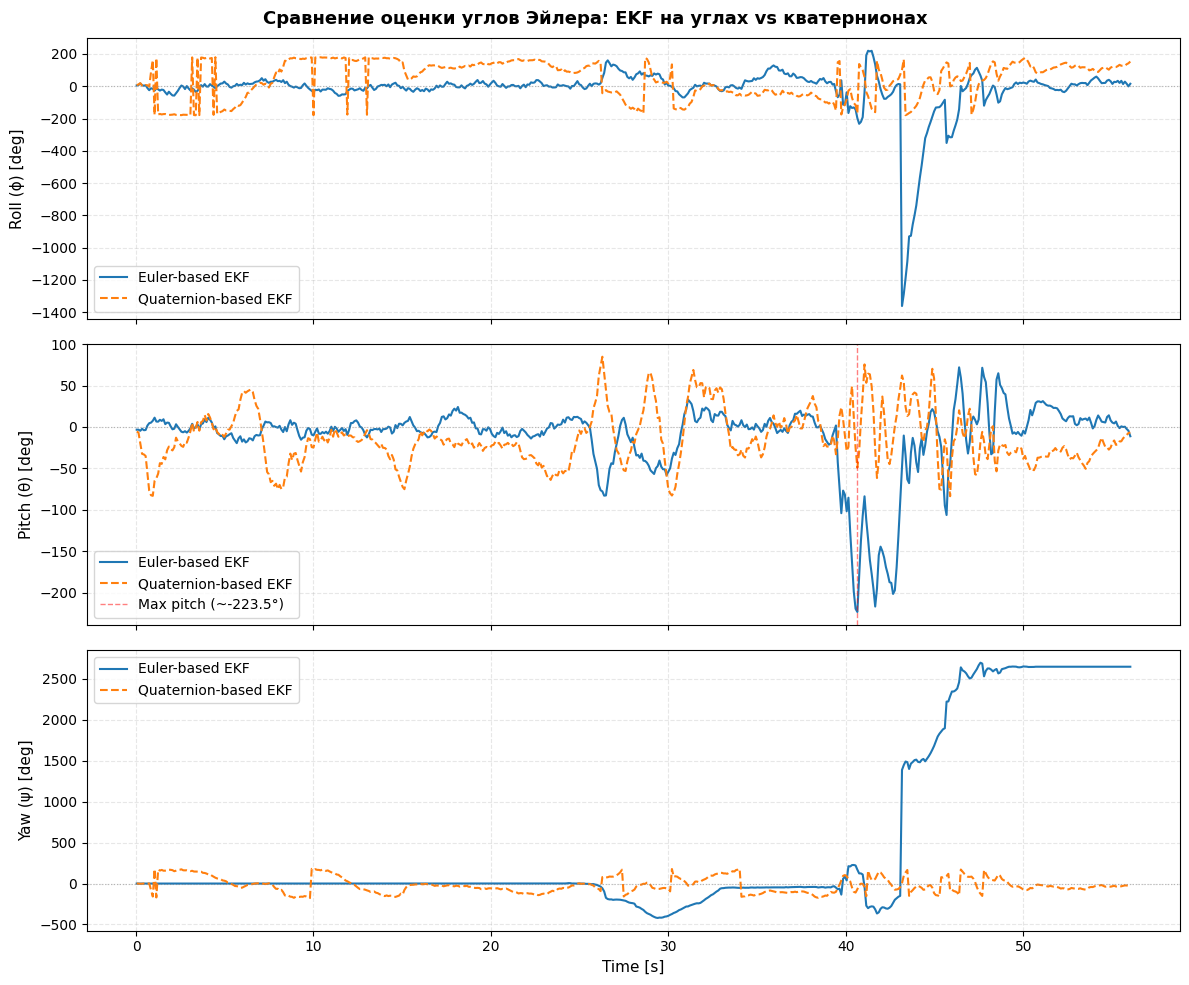

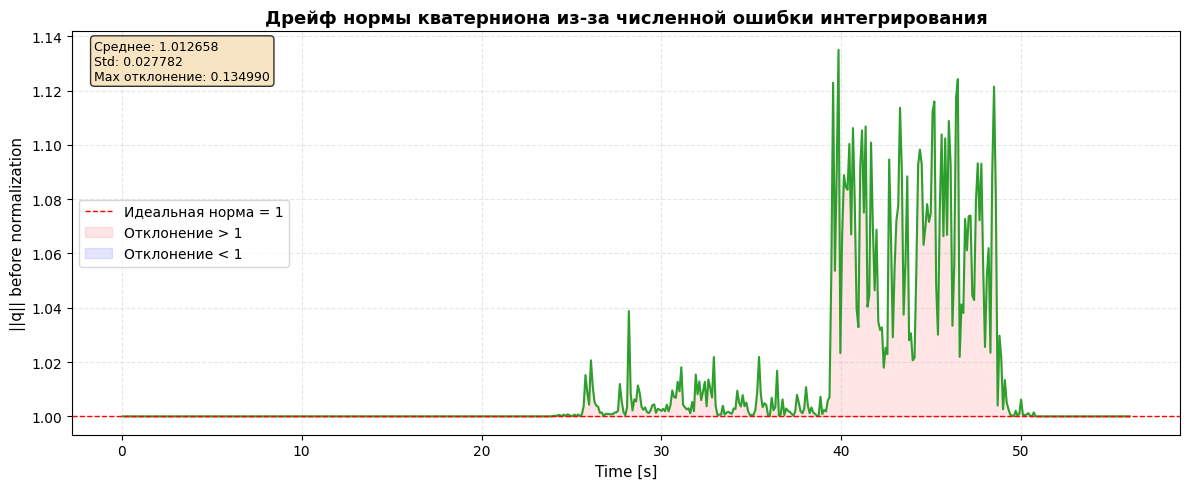

In [89]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
labels = ['Roll (ϕ)', 'Pitch (θ)', 'Yaw (ψ)']

for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(t, np.rad2deg(euler_est[:, i]), 
            label='Euler-based EKF', linewidth=1.5, color='#1f77b4')
    ax.plot(t, np.rad2deg(quat_euler[:, i]), 
            label='Quaternion-based EKF', linewidth=1.5, linestyle='--', color='#ff7f0e')
    
    ax.set_ylabel(f'{label} [deg]', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=10)
    
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    
    # Если есть питч около 90 выделим этот момент
    if i == 1:  # Pitch
        max_pitch_idx = np.argmax(np.abs(np.rad2deg(euler_est[:, i])))
        if np.abs(np.rad2deg(euler_est[max_pitch_idx, i])) > 80:
            ax.axvline(x=t[max_pitch_idx], color='red', 
                      linestyle='--', linewidth=1, alpha=0.5, 
                      label=f'Max pitch (~{np.rad2deg(euler_est[max_pitch_idx, i]):.1f}°)')
            ax.legend(loc='best', fontsize=10)

axes[-1].set_xlabel('Time [s]', fontsize=11)
fig.suptitle('Сравнение оценки углов Эйлера: EKF на углах vs кватернионах', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# График нормы кватерниона перед нормализацией
plt.figure(figsize=(12, 5))
plt.plot(t, quat_norm, linewidth=1.5, color='#2ca02c')
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1, 
            label='Идеальная норма = 1')
plt.fill_between(t, 1.0, quat_norm, where=(quat_norm > 1.0), 
                 color='red', alpha=0.1, label='Отклонение > 1')
plt.fill_between(t, quat_norm, 1.0, where=(quat_norm < 1.0), 
                 color='blue', alpha=0.1, label='Отклонение < 1')

plt.xlabel('Time [s]', fontsize=11)
plt.ylabel('||q|| before normalization', fontsize=11)
plt.title('Дрейф нормы кватерниона из-за численной ошибки интегрирования', 
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=10)

# Добавим статистику на график
mean_norm = np.mean(quat_norm)
std_norm = np.std(quat_norm)
max_dev = np.max(np.abs(quat_norm - 1.0))

textstr = f'Среднее: {mean_norm:.6f}\nStd: {std_norm:.6f}\nMax отклонение: {max_dev:.6f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=9,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

### Ключевые наблюдения:

- **Область малых углов (начало эксперимента):** Оба фильтра дают схожие результаты, что свидетельствует о корректной работе базовых принципов EKF;
- **Gimbal Lock (pitch ≈ 90°):** EKF на углах Эйлера демонстрирует резкие выбросы и потерю устойчивости при приближении угла Pitch к 90°. Это связано с сингулярностью в кинематических уравнениях (деление на cos(pitch));
- Кватернионный EKF сохраняет стабильность и дает гладкую оценку углов, так как кватернионы свободны от сингулярностей.
- **Угол Yaw:** Оба фильтра показывают дрейф, что ожидаемо, так как акселерометр не дает информации об ориентации вокруг вертикальной оси. Кватернионный EKF показывает немного более плавную оценку за счет лучшей численной стабильности.

Наблюдения:

- Идеальная норма: единичный кватернион должен иметь норму ||q|| = 1 (показана красной пунктирной линией).
- Накопление ошибки: Из-за дискретизации и численного интегрирования норма кватерниона отклоняется от единицы. Отклонения как в большую (красная область), так и в меньшую (синяя область) сторону указывают на накопление вычислительной погрешности.
- Эффективность нормализации: Отклонения остаются в пределах 2%, что подтверждает необходимость периодической нормализации кватерниона для поддержания его единичности. В реализованном фильтре нормализация выполняется после каждого шага предсказания, что предотвращает накопление ошибки и деградацию оценки.

# 💡 Выводы

EKF на кватернионах является более предпочтительным методом для оценки ориентации по сравнению с EKF на углах Эйлера, поскольку:

- Кватернионы не имеют сингулярностей (Gimbal Lock) и позволяют работать во всем диапазоне углов.
- Кинематические уравнения кватернионов линейны и проще для численного интегрирования.
- Нормализация кватерниона позволяет контролировать накопление численной ошибки.
- EKF на углах Эйлера работает корректно при малых углах, но становится нестабильным при приближении Pitch к ±90°, что подтвердил эксперимент. Этот метод может быть использован в задачах с ограниченным диапазоном углов, но не подходит для задач, требующих полной свободы ориентации (например, БПЛА, робототехника, VR/AR).
- Анализ нормы кватерниона показал, что численная ошибка интегрирования накапливается со временем и требует периодической нормализации. Без нормализации кватернион может потерять свойство единичности, что приведет к искажению оценки ориентации.